# 179. Largest Number
https://leetcode.com/problems/largest-number/

## Complexity Comparison

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Custom Comparator Sort | O(n log n * k) | O(n * k) | k = avg digit count, optimal |
| Brute Force Permutations | O(n! * n * k) | O(n * k) | Impractical for large n |

## Methodology

Given a list of non-negative integers, arrange them to form the largest number.
The key insight is the custom comparator: for two numbers a and b, compare the
concatenations ab vs ba. If ab > ba, then a should come before b. After sorting,
concatenate all numbers. Handle the edge case where all numbers are 0 (return "0").

## Solutions

### C#

In [ ]:
using System;
using System.Linq;

public class Solution
{
    public string LargestNumber(int[] nums)
    {
        var strs = nums.Select(n => n.ToString()).ToArray();
        Array.Sort(strs, (a, b) => (b + a).CompareTo(a + b));
        if (strs[0] == "0") return "0";
        return string.Join("", strs);
    }
}

// Test
var sol = new Solution();
Console.WriteLine(sol.LargestNumber(new[] { 10, 2 }));       // "210"
Console.WriteLine(sol.LargestNumber(new[] { 3, 30, 34, 5, 9 })); // "9534330"
Console.WriteLine(sol.LargestNumber(new[] { 0, 0 }));        // "0"

### Python

In [ ]:
// Python solution:
//
// from functools import cmp_to_key
//
// class Solution:
//     def largestNumber(self, nums: list[int]) -> str:
//         strs = [str(n) for n in nums]
//         strs.sort(key=cmp_to_key(lambda a, b: -1 if a + b > b + a else 1))
//         result = ''.join(strs)
//         return '0' if result[0] == '0' else result

### Go

In [ ]:
// Go solution:
//
// import (
//     "sort"
//     "strconv"
//     "strings"
// )
//
// func largestNumber(nums []int) string {
//     strs := make([]string, len(nums))
//     for i, n := range nums {
//         strs[i] = strconv.Itoa(n)
//     }
//     sort.Slice(strs, func(i, j int) bool {
//         return strs[i]+strs[j] > strs[j]+strs[i]
//     })
//     if strs[0] == "0" {
//         return "0"
//     }
//     return strings.Join(strs, "")
// }

### Rust

In [ ]:
// Rust solution:
//
// impl Solution {
//     pub fn largest_number(nums: Vec<i32>) -> String {
//         let mut strs: Vec<String> = nums.iter().map(|n| n.to_string()).collect();
//         strs.sort_by(|a, b| {
//             let ab = format!("{}{}", b, a);
//             let ba = format!("{}{}", a, b);
//             ab.cmp(&ba)
//         });
//         if strs[0] == "0" {
//             return "0".to_string();
//         }
//         strs.join("")
//     }
// }

## Example Scenarios

1. **Common Case:** `nums = [10, 2]` $\Rightarrow$ `"210"`. Compare concatenations: `"210"` vs `"102"`. Since `"210" > "102"`, place 2 before 10. WHY tricky: lexicographic comparison of individual digits is insufficient — `"10" > "2"` lexicographically, but 2 should come first. $O(n \log n \cdot k)$ time.

2. **Slightly Complex:** `nums = [3, 30, 34, 5, 9]` $\Rightarrow$ `"9534330"`. Key comparison: 3 vs 30 — `"330" > "303"`, so 3 before 30. Also 3 vs 34 — `"334" < "343"`, so 34 before 3. The sorted order is [9, 5, 34, 3, 30]. WHY tricky: elements with shared prefixes require careful pairwise concatenation comparison. Transitivity of the comparator is guaranteed.

3. **Edge Case (Time):** `nums` has $10^5$ elements, each up to $10^9$ (10 digits). Each comparison concatenates two 10-digit strings. Total: $O(n \log n \cdot k) = O(10^5 \times 17 \times 10) \approx 1.7 \times 10^7$ character comparisons. Output string: $10^5 \times 10 = 10^6$ characters.

4. **Edge Case (Space):** `nums = [0, 0, ..., 0]` ($10^5$ zeros) $\Rightarrow$ `"0"`. All zeros — the concatenation would be `"000...0"` ($10^5$ zeros). The edge-case check `if strs[0] == "0": return "0"` prevents this. WHY tricky: without this check, allocating and returning a $10^5$-character string of zeros is numerically correct but violates the "no leading zeros" requirement.

5. **Almost-Impossible but Plausible:** `nums = [12, 121]` $\Rightarrow$ `"12121"`. One number is a prefix of the other. Compare `"12121"` vs `"12112"`: at position 3, '2' > '1', so 12 before 121. WHY tricky: prefix-overlap is the hardest case. Without the concatenation trick, you might incorrectly choose the longer number 121 first.

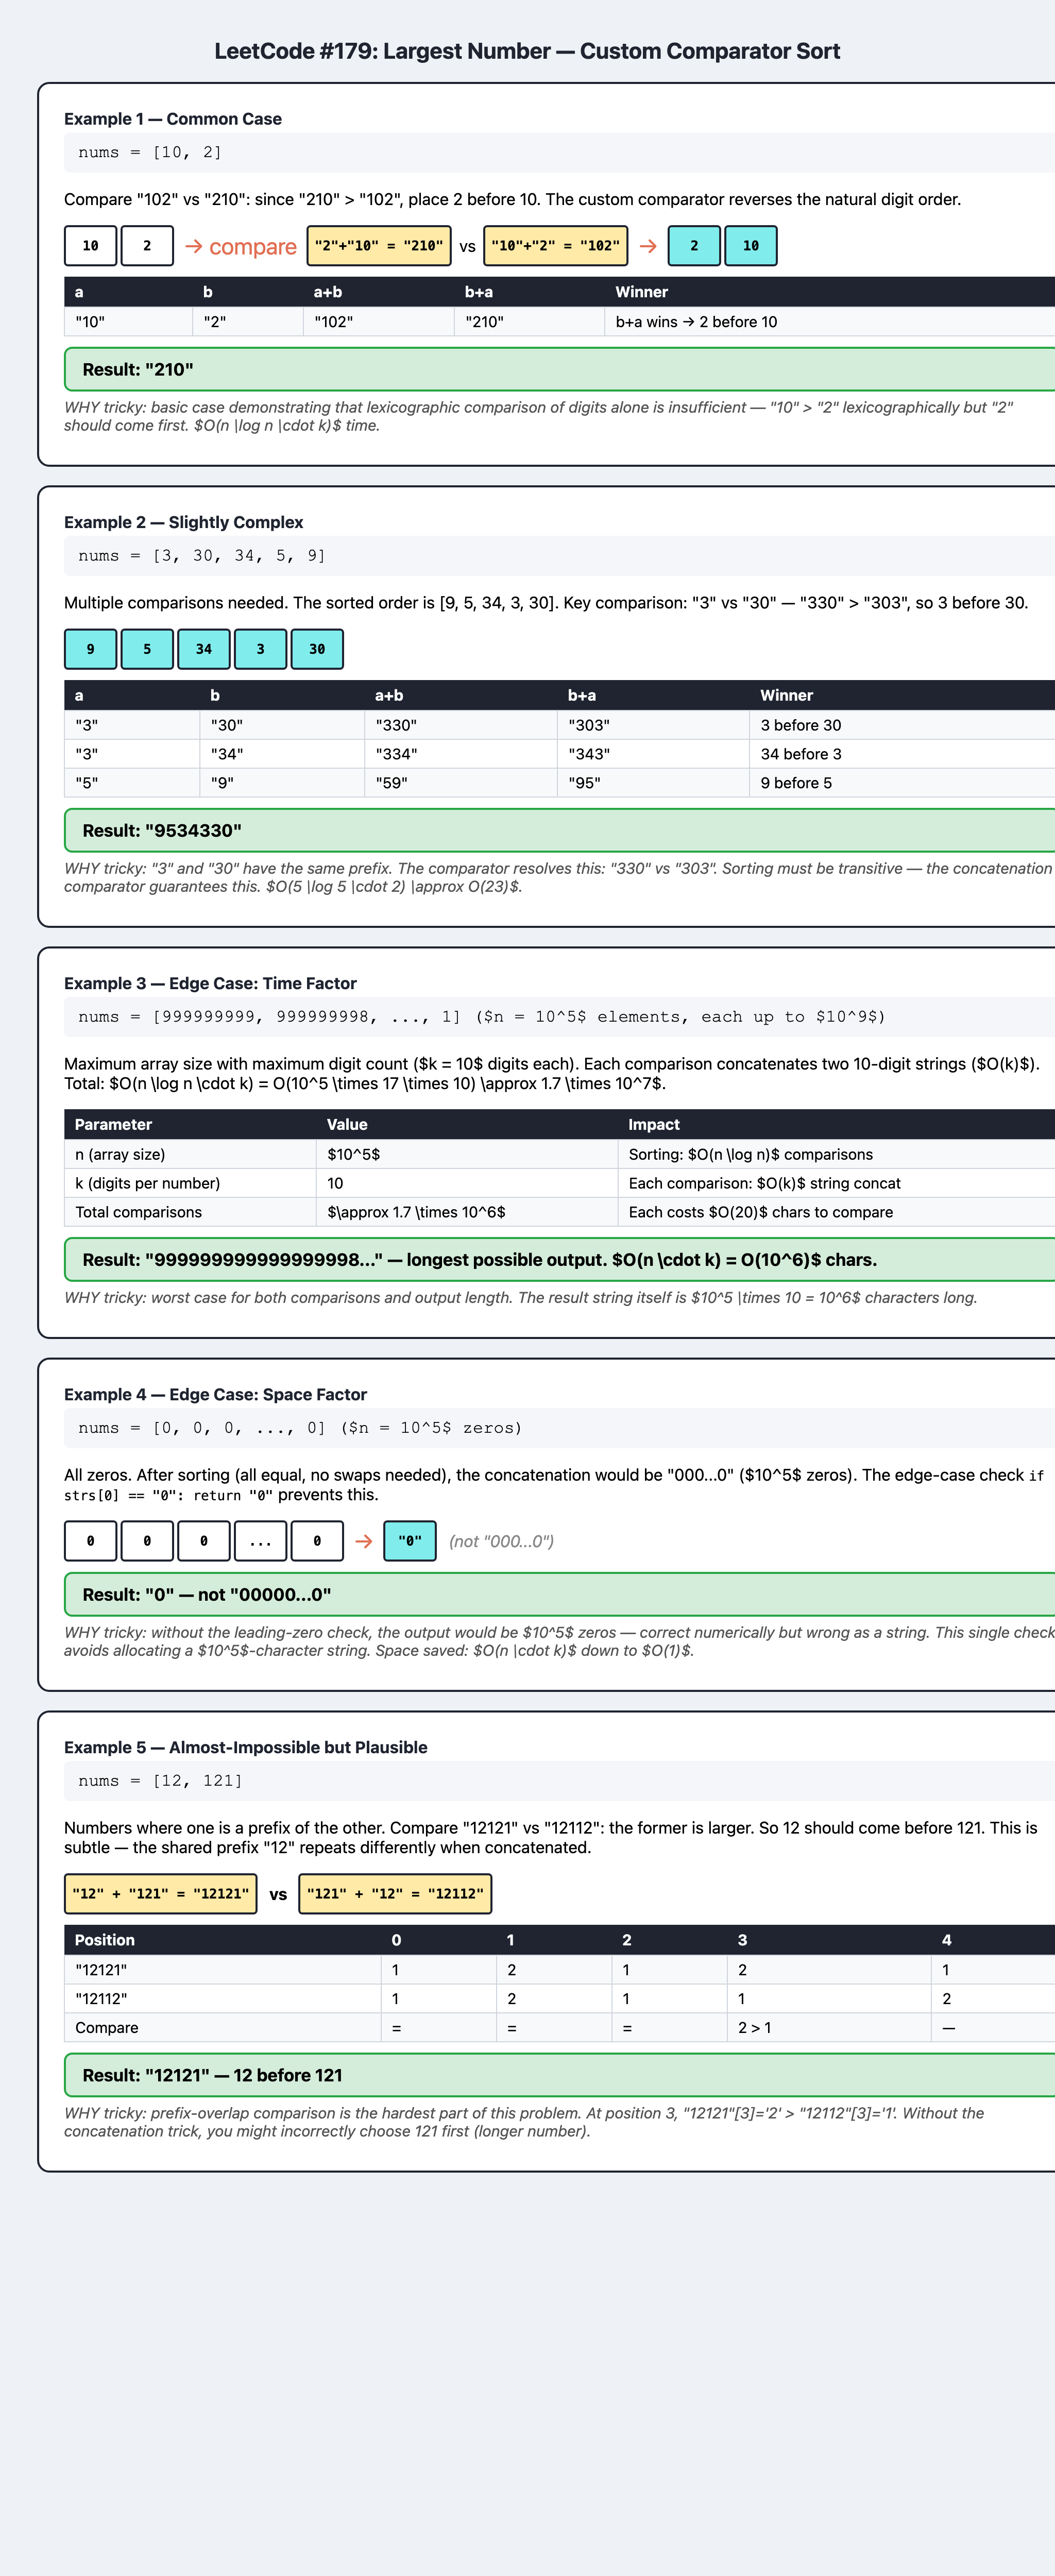